# Synthetic (FFN, FNN, PCA)

In [2]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
os.chdir('c:\\Users\\cqyzxy\\Downloads\\jld\\jld')
f = h5py.File("PDE_1d_glob_new_center.jld2", "r")
data_I = np.array(np.array(f['data_I_center']))
data_c = np.array(np.array(f['data_c_center']))
data_h = np.array(np.array(f['data_h_center']))
t = np.linspace(0, 1, 601).reshape(601, 1)


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term



In [25]:

train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]



In [26]:
data_I.shape

(27369, 601)

In [26]:
X_train = data_i_train.astype(np.float32)
y_train_c = data_c_train.astype(np.float32)
X_test = data_i_test.astype(np.float32)
y_test_c = data_c_test.astype(np.float32)
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)


# FFN

In [27]:

m = data_I.shape[1]
dim_x = 1
net_c = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 300, 200, 200, m]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 401801


In [28]:
model_c = dde.Model(data_c, net_c)
model_c.compile("adam", lr=0.001,metrics=["MSE"])
losshistory_c, train_state_c = model_c.train(iterations=500, display_every=50)


Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.201903 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [6.16e+00]    [6.36e+00]    [6.36e+00]    
50        [2.05e-01]    [2.22e-01]    [2.22e-01]    
100       [1.19e-01]    [1.32e-01]    [1.32e-01]    
150       [7.89e-02]    [9.54e-02]    [9.54e-02]    
200       [5.14e-02]    [6.98e-02]    [6.98e-02]    
250       [3.42e-02]    [5.36e-02]    [5.36e-02]    
300       [2.42e-02]    [4.44e-02]    [4.44e-02]    
350       [1.85e-02]    [3.90e-02]    [3.90e-02]    
400       [1.46e-02]    [3.65e-02]    [3.65e-02]    
450       [1.23e-02]    [3.47e-02]    [3.47e-02]    
500       [1.06e-02]    [3.37e-02]    [3.37e-02]    

Best model at step 500:
  train loss: 1.06e-02
  test loss: 3.37e-02
  test metric: [3.37e-02]

'train' took 108.108799 s



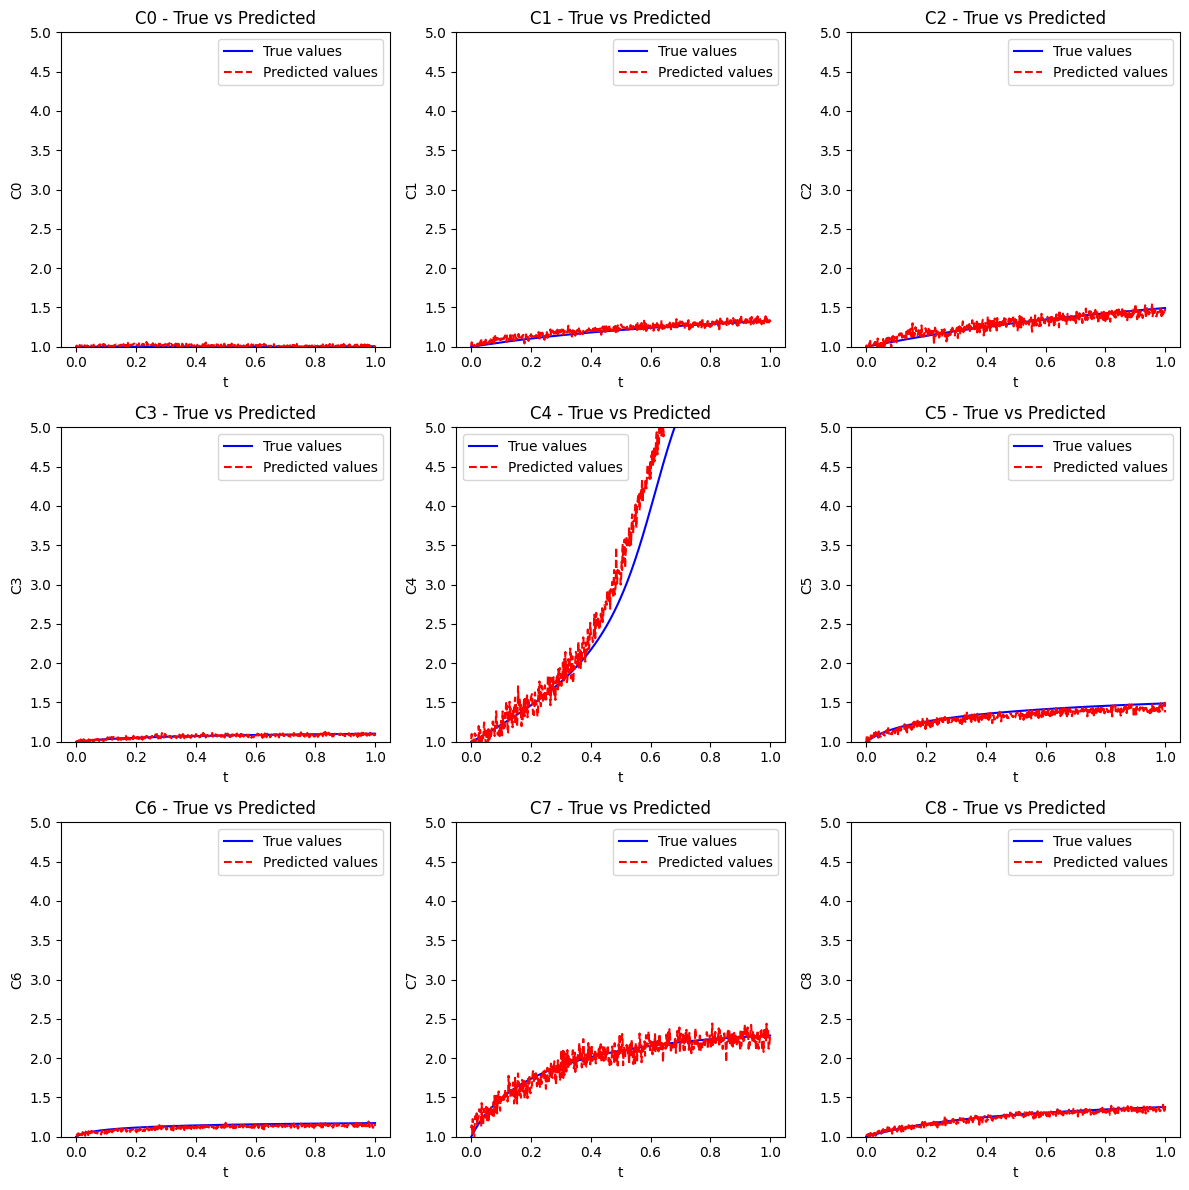

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(9): 
    row, col = divmod(i, 3)  
    ax = axes[row, col]  
    pred_c = model_c.predict(data_i_test[20*i].reshape(1, -1))
  


    # Plot true vs predicted values for the i-th feature
    ax.plot(t,data_c_test[20*i].reshape(-1,1), label="True values", color="b")
    #ax.plot(t,data_c_test[i], label="True values", color="b")
    #ax.plot(t,pred_c.reshape(-1,1), label="Predicted values", color="r", linestyle="--")
    ax.plot(t,pred_c.reshape(-1,1), label="Predicted values", color="r", linestyle="--")
    
    ax.set_xlabel("t")
    ax.set_ylabel(f"C{i}")
    ax.set_title(f"C{i} - True vs Predicted")
    
    ax.set_ylim(1, 5)
    
    ax.legend()
fig.tight_layout()
#plt.savefig("all_data_c_FFN.pdf")
plt.show()


In [29]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

m = data_I.shape[1]
dim_x = 1
net_h = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5,1,2]
)
model_h = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001)
losshistory_h, train_state_h = model_h.train(iterations=500, display_every=50)


Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.200490 s

Training model...

Step      Train loss    Test loss     Test metric
0         [8.26e-01]    [8.22e-01]    []  
50        [1.11e-02]    [1.16e-02]    []  
100       [4.95e-03]    [5.32e-03]    []  
150       [3.15e-03]    [3.47e-03]    []  
200       [2.18e-03]    [2.47e-03]    []  
250       [1.57e-03]    [1.86e-03]    []  
300       [1.21e-03]    [1.50e-03]    []  
350       [9.93e-04]    [1.28e-03]    []  
400       [8.47e-04]    [1.13e-03]    []  
450       [7.31e-04]    [1.02e-03]    []  
500       [6.89e-04]    [9.76e-04]    []  

Best model at step 500:
  train loss: 6.89e-04
  test loss: 9.76e-04
  test metric: []

'train' took 168.894957 s



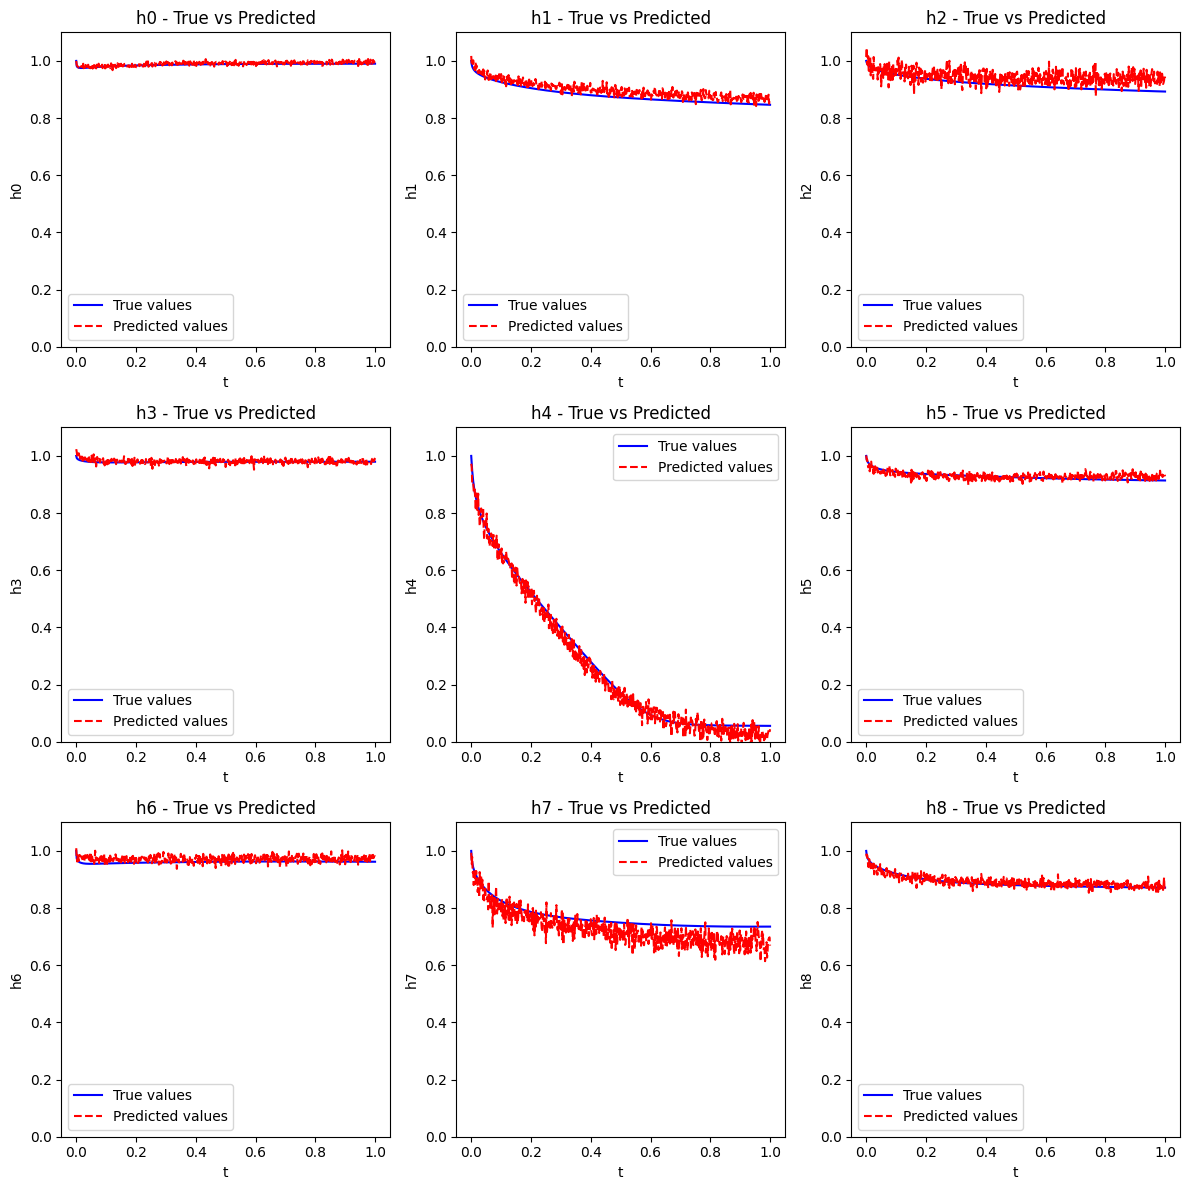

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(9): 
    row, col = divmod(i, 3)  
    ax = axes[row, col]  
    pred_h = model_h.predict(data_i_test[20*i].reshape(1,-1)).reshape(-1,1)

    ax.plot(t,data_h_test[20*i].reshape(-1,1), label="True values", color="b")
    ax.plot(t,pred_h.reshape(-1,1), label="Predicted values", color="r", linestyle="--")
    
    
    ax.set_xlabel("t")
    ax.set_ylabel(f"h{i}")
    ax.set_title(f"h{i} - True vs Predicted")
    
    ax.set_ylim(0, 1.1)
    
    ax.legend()
fig.tight_layout()
#plt.savefig("all_data_h_FFN.pdf")
plt.show()


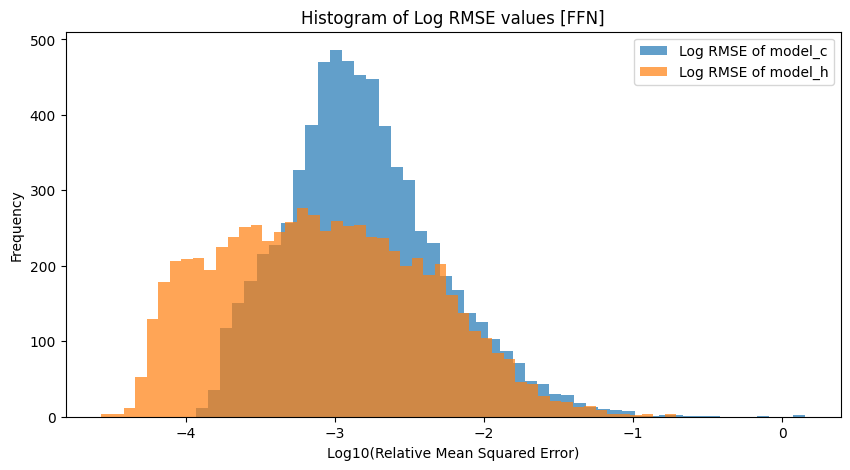

In [ ]:
predictions_c = model_c.predict(data_i_test)  # Ensure model_c is defined
predictions_h = model_h.predict(data_i_test)  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.sum((predictions_c - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.sum((predictions_h - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values [FFN]')
plt.legend()
plt.show()


# FNN

In [ ]:

m = data_I.shape[1]
dim_x = 1
net_h = dde.nn.fnn.FNN(
    [m, 200, 200, 200, m],
    "relu",
    "Glorot normal",
)
model_h_fnn = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h_fnn.compile("adam", lr=0.001)
losshistory_h, train_state_h = model_h_fnn.train(iterations=500, display_every=50)


Compiling model...
Building feed-forward neural network...
'build' took 0.031246 s

'compile' took 0.146198 s

Training model...

Step      Train loss    Test loss     Test metric
0         [6.91e-01]    [6.86e-01]    []  
50        [1.18e-02]    [1.18e-02]    []  
100       [7.51e-03]    [7.64e-03]    []  
150       [6.37e-03]    [6.52e-03]    []  
200       [6.23e-03]    [6.43e-03]    []  
250       [6.50e-03]    [6.71e-03]    []  
300       [6.22e-03]    [6.50e-03]    []  
350       [1.83e-02]    [1.87e-02]    []  
400       [5.18e-03]    [5.37e-03]    []  
450       [5.29e-03]    [5.51e-03]    []  
500       [5.01e-03]    [5.18e-03]    []  

Best model at step 500:
  train loss: 5.01e-03
  test loss: 5.18e-03
  test metric: []

'train' took 54.603260 s



In [29]:
m = data_I.shape[1]
dim_x = 1
net_c = dde.nn.fnn.FNN(
    [m, 200, 200, 200, m],
    "relu",
    "Glorot normal",
)
model_c_fnn = dde.Model(data_c, net_c)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c_fnn.compile("adam", lr=0.001)
losshistory_c, train_state_c = model_c_fnn.train(iterations=500, display_every=50)


Compiling model...
Building feed-forward neural network...
'build' took 0.032797 s

'compile' took 0.165149 s

Training model...

Step      Train loss    Test loss     Test metric
0         [6.07e+00]    [6.26e+00]    []  
50        [3.01e-01]    [3.11e-01]    []  
100       [1.94e-01]    [2.03e-01]    []  
150       [1.54e-01]    [1.60e-01]    []  
200       [1.36e-01]    [1.39e-01]    []  
250       [1.23e-01]    [1.25e-01]    []  
300       [1.14e-01]    [1.15e-01]    []  
350       [1.06e-01]    [1.08e-01]    []  
400       [1.00e-01]    [1.01e-01]    []  
450       [9.92e-02]    [9.99e-02]    []  
500       [9.25e-02]    [9.37e-02]    []  

Best model at step 500:
  train loss: 9.25e-02
  test loss: 9.37e-02
  test metric: []

'train' took 57.627080 s



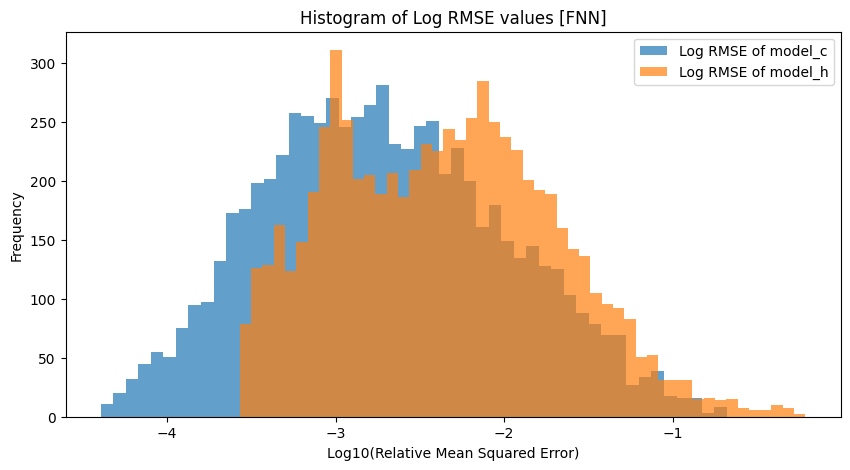

In [ ]:
predictions_c = model_c_fnn.predict(data_i_test)  # Ensure model_c is defined
predictions_h = model_h_fnn.predict(data_i_test)  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.sum((predictions_c - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.sum((predictions_h - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values [FNN]')
plt.legend()
plt.show()


# PCA

In [156]:
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
pca_i = PCA(n_components=0.999, svd_solver='full')
pca_i.fit(data_i_train)

# Number of principal components
n_components = pca_i.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_i_train_pca = pca_i.transform(data_i_train)
data_i_train_reconstructed = pca_i.inverse_transform(data_i_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_train - data_i_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca = pca_i.transform(data_i_test)
data_i_test_reconstructed = pca_i.inverse_transform(data_i_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_test - data_i_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")


Number of principal components: 4
Mean Squared Error for data_i_train: 2.8754344547990236e-05
Mean Squared Error for data_i_test: 3.0703700132327006e-05


In [157]:
pca_c = PCA(n_components=0.99999, svd_solver='full')
pca_c.fit(data_c_train)

# Number of principal components
n_components = pca_c.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_c_train_pca = pca_c.transform(data_c_train)
data_c_train_reconstructed = pca_c.inverse_transform(data_c_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_c_train - data_c_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_train: {mse_train}")

# Transform and inverse transform data_i_test
data_c_test_pca = pca_c.transform(data_c_test)
data_c_test_reconstructed = pca_c.inverse_transform(data_c_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_c_test - data_c_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")



Number of principal components: 13
Mean Squared Error for data_c_train: 1.752298543959823e-05
Mean Squared Error for data_c_test: 2.076469482326079e-05


In [158]:
pca_h = PCA(n_components=0.9999, svd_solver='full')
pca_h.fit(data_h_train)

# Number of principal components
n_components = pca_h.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_h_train_pca = pca_h.transform(data_h_train)
data_h_train_reconstructed = pca_h.inverse_transform(data_h_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_h_train - data_h_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_train: {mse_train}")

# Transform and inverse transform data_i_test
data_h_test_pca = pca_h.transform(data_h_test)
data_h_test_reconstructed = pca_h.inverse_transform(data_h_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_h_test - data_h_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")


Number of principal components: 6
Mean Squared Error for data_h_train: 2.4277787854257165e-06
Mean Squared Error for data_c_test: 2.774358871670191e-06


In [159]:
X_train = data_i_train_pca.astype(np.float32)
y_train_c = data_c_train_pca.astype(np.float32)
X_test = data_i_test_pca.astype(np.float32)
y_test_c = data_c_test_pca.astype(np.float32)
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)
m = 601
dim_x = 1
net_c = dde.nn.fnn.FNN(
    [4, 400, 300, 200, 13],
    "relu",
    "Glorot normal",
)
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [4, 400, 300, 200, 13]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 185113


In [160]:
model_c_pca = dde.Model(data_c, net_c)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c_pca.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory_c, train_state_c = model_c_pca.train(iterations=1000, display_every=100)


Compiling model...
Building feed-forward neural network...
'build' took 0.090981 s

'compile' took 0.255591 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.14e+02]    [1.18e+02]    [1.00e+00]    
100       [1.39e+01]    [1.47e+01]    [3.53e-01]    
200       [6.94e+00]    [7.26e+00]    [2.48e-01]    
300       [6.18e+00]    [6.58e+00]    [2.36e-01]    
400       [5.79e+00]    [6.15e+00]    [2.29e-01]    
500       [5.52e+00]    [5.81e+00]    [2.22e-01]    
600       [5.34e+00]    [5.68e+00]    [2.20e-01]    
700       [5.25e+00]    [5.50e+00]    [2.16e-01]    
800       [6.06e+00]    [6.53e+00]    [2.35e-01]    
900       [4.97e+00]    [5.19e+00]    [2.10e-01]    
1000      [4.82e+00]    [5.06e+00]    [2.07e-01]    

Best model at step 1000:
  train loss: 4.82e+00
  test loss: 5.06e+00
  test metric: [2.07e-01]

'train' took 77.391620 s



In [161]:
y_train_h = data_h_train_pca.astype(np.float32)
y_test_h = data_h_test_pca.astype(np.float32)
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)
m = 601
dim_x = 1
net_h = dde.nn.fnn.FNN(
    [4, 200, 200, 200, 6],
    "relu",
    "Glorot normal",
)
model_h_pca = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h_pca.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory_h, train_state_h = model_h_pca.train(iterations=2000, display_every=100)


Compiling model...
Building feed-forward neural network...
'build' took 0.042726 s

'compile' took 0.180268 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [5.95e+00]    [5.99e+00]    [9.87e-01]    
100       [3.83e-01]    [3.77e-01]    [2.47e-01]    
200       [2.01e-01]    [1.96e-01]    [1.78e-01]    
300       [1.66e-01]    [1.65e-01]    [1.64e-01]    
400       [1.43e-01]    [1.44e-01]    [1.53e-01]    
500       [1.23e-01]    [1.27e-01]    [1.43e-01]    
600       [1.23e-01]    [1.28e-01]    [1.44e-01]    
700       [1.05e-01]    [1.10e-01]    [1.34e-01]    
800       [1.06e-01]    [1.11e-01]    [1.34e-01]    
900       [9.57e-02]    [1.01e-01]    [1.28e-01]    
1000      [9.37e-02]    [1.00e-01]    [1.27e-01]    
1100      [9.17e-02]    [9.82e-02]    [1.26e-01]    
1200      [9.15e-02]    [9.91e-02]    [1.27e-01]    
1300      [8.68e-02]    [9.41e-02]    [1.24e-01]    
1400      [8.52e-02]    [9.32e-02]    [1.23e-01]    
1500      [9.09e-02]  

0.003732017638927507 0.009766485132797013


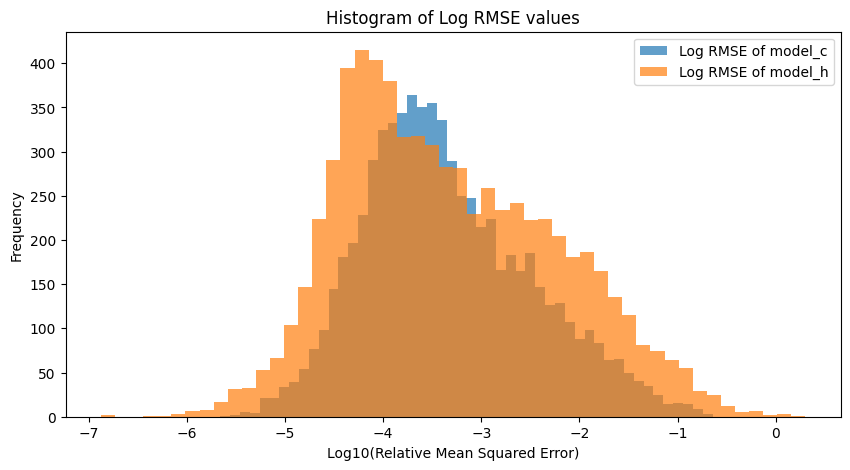

In [44]:
predictions_c = pca_c.inverse_transform(model_c_pca.predict(data_i_test_pca))  # Ensure model_c is defined
predictions_h = pca_h.inverse_transform(model_h_pca.predict(data_i_test_pca))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2), axis=1)  # Averaging across time points

print(np.mean(rmse_c), np.mean(rmse_h))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()



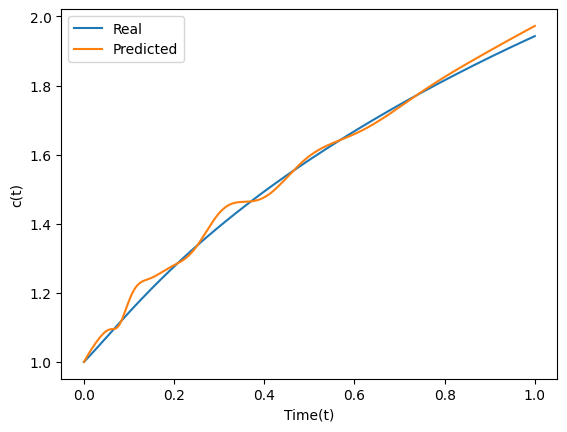

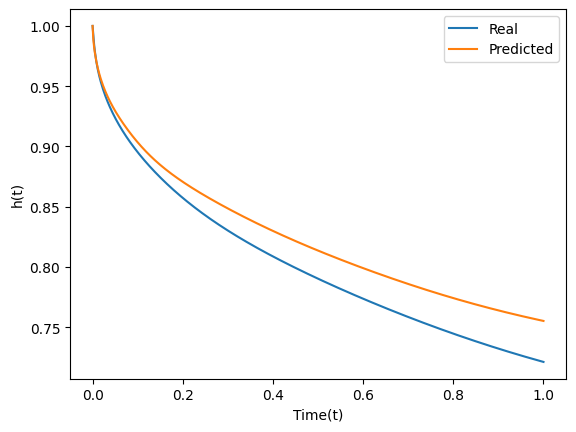

In [ ]:
n = np.random.randint(0, len(data_h_test))
pred_c = pca_c.inverse_transform(model_c_pca.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h_pca.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()


# Compare PDE model predictions with ODE results

In [91]:
import re

# Read file
with open("dump.txt", "r") as file:
    lines = file.readlines()

# Storage
data_blocks = {}
current_block = None
parameters = {}
time_series = []

# Regular expressions
param_pattern = re.compile(r"(\w+)\s*=\s*([-\d\.eE+]+)")
data_pattern = re.compile(r"^([\d.]+),\s*([\d.]+)")

for line in lines:
    line = line.strip()

    # Detect a new block (e.g. 01_visit1_t10_box1)
    if "visit" in line:
        if current_block:
            # Save the previous block
            data_blocks[current_block] = {
                "params": parameters,
                "data": time_series
            }
        # Start new block
        current_block = line
        parameters = {}
        time_series = []

    # Parse parameters like f0, ts, etc.
    elif "=" in line and not line.startswith("-"):
        match = param_pattern.match(line)
        if match:
            key = match.group(1)
            val = float(match.group(2))
            parameters[key] = val

    # Parse time-series data
    elif "," in line:
        match = data_pattern.match(line)
        if match:
            t = float(match.group(1))
            y = float(match.group(2))
            time_series.append((t, y))

# Don’t forget to save the last block
if current_block:
    data_blocks[current_block] = {
        "params": parameters,
        "data": time_series
    }

    

In [146]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def solve_TF_model_from_block(params):
    """
    olves the TF ODE model using parameters from a parsed text block.
    Expected keys in params: f0, ts, h0, J, b1, b2
    Returns: t (601,), h(t), c(t)
    """
    # Fixed physical constants
    p0 = 12e-6       # Pa
    vw = 1.8e-5      # m³/mol
    c0 = 302         # mol/m³
    sigma_0 = 0.045
    mu = 1.3e-3
    Df = 0.39e-9
    D0 = 1.6e-9
    DS = 3e-8

    # Convert and extract input params
    d = params['h0'] * 1e-6                   # assumed unitless or fixed
    t_s = params['ts']          # seconds
    f0 = params['f0']           # s⁻¹
    b1_prime = params['b1']     # s⁻¹
    b2_prime = params['b2']     # s⁻¹

    # Derived quantities
    Pc = (p0 * vw * c0) / (d / t_s)
    v_prime = params['J'] * 1e-6 / 60       # m/s
    b1 = t_s * b1_prime
    b2 = t_s * b2_prime
    v = (t_s * v_prime) / d

    # Define ODE system
    def TF(t, u):
        h, c = u
        g = b1 * np.exp(-b2 * t)
        dh = -g * h + Pc * (c - 1) - v
        dc = -g * c - dh * c / h
        return [dh, dc]

    # Initial conditions and time span
    u0 = [1.0, 1.0]
    t_span = (0.0, 1.0)
    t_eval = np.linspace(0, 1, 601)

    # Solve
    sol = solve_ivp(TF, t_span, u0, method="RK45", t_eval=t_eval)
    return sol.t, sol.y[0], sol.y[1]

Processing 06_visit2_t9_box2...


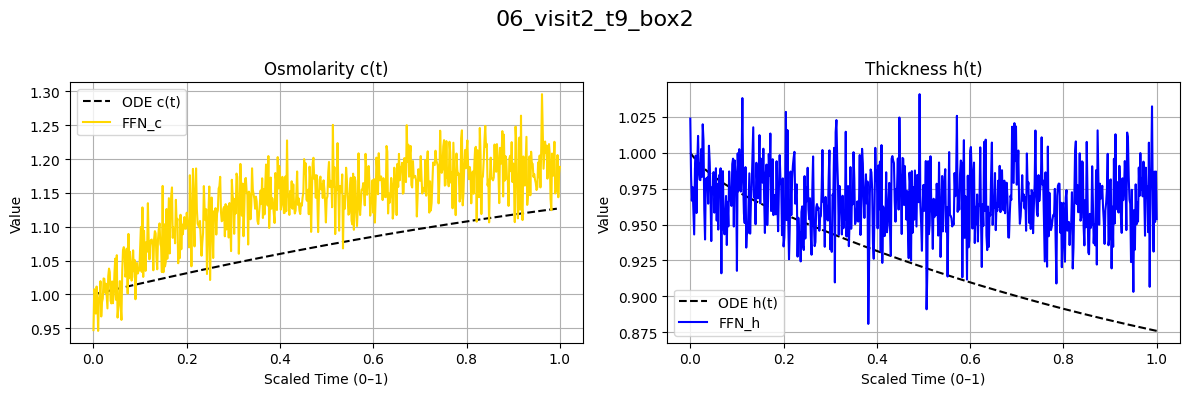

In [ ]:
import random
from scipy.interpolate import PchipInterpolator
block = random.choice(list(data_blocks.keys()))
block_data = data_blocks[block]

print(f"Processing {block}...")

try:
    params = block_data["params"]
    times, values = zip(*block_data["data"])
    times = np.array(times)
    values = np.array(values)

    if len(times) < 2 or values[0] == 0:
        print(f"Skipping {block} due to insufficient data or division by zero.")
    else:
        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        # Predict with models
        predictions_c = model_c.predict(I_interp.reshape(1, -1)).flatten()
        predictions_h = model_h.predict(I_interp.reshape(1, -1)).flatten()

        # Solve ODE
        t, h_ode, c_ode = solve_TF_model_from_block(params)

        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        axs[0].plot(t, c_ode, label="ODE c(t)", color="black", linestyle="--")
        axs[0].plot(t_interp, predictions_c, label="FFN_c", color="gold")
        axs[0].set_title("Osmolarity c(t)")
        axs[0].set_xlabel("Scaled Time (0–1)")
        axs[0].set_ylabel("Value")
        axs[0].grid(True)
        axs[0].legend()

        axs[1].plot(t, h_ode, label="ODE h(t)", color="black", linestyle="--")
        axs[1].plot(t_interp, predictions_h, label="FFN_h", color="blue")
        axs[1].set_title("Thickness h(t)")
        axs[1].set_xlabel("Scaled Time (0–1)")
        axs[1].set_ylabel("Value")
        axs[1].grid(True)
        axs[1].legend()

        fig.suptitle(f"{block}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

except Exception as e:
    print(f"Error processing {block}: {e}")

    


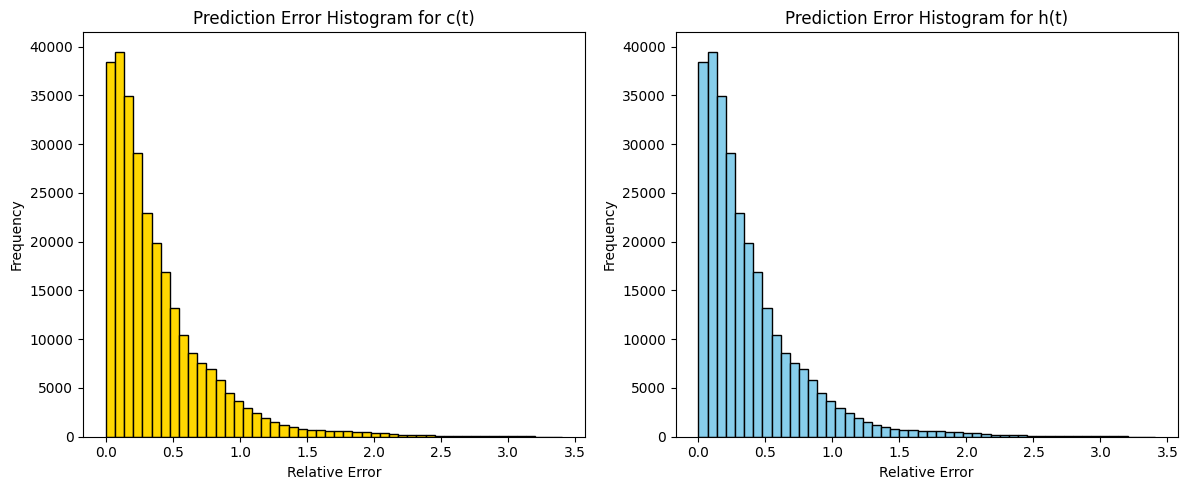

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

errors_c = []
errors_h = []

for block, block_data in data_blocks.items():
    try:
        params = block_data["params"]
        times, values = zip(*block_data["data"])
        times = np.array(times)
        values = np.array(values)

        if len(times) < 2 or values[0] == 0:
            continue

        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        # Predict
        pred_c = model_c.predict(I_interp.reshape(1, -1)).flatten()
        pred_h = model_h.predict(I_interp.reshape(1, -1)).flatten()

        # Ground truth
        t, h_ode, c_ode = solve_TF_model_from_block(params)

        # Interpolate ODE to match prediction time grid
        c_true = np.interp(t_interp, t, c_ode)
        h_true = np.interp(t_interp, t, h_ode)

        # Error: per-point absolute error
        errors_c.extend(np.abs((pred_c - c_true) / c_true))
        errors_h.extend(np.abs((pred_c - c_true) / c_true))

    except Exception as e:
        print(f"Skipping {block} due to error: {e}")
        continue

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors_c, bins=50, color="gold", edgecolor="black")
plt.title("Prediction Error Histogram for c(t)")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(errors_h, bins=50, color="skyblue", edgecolor="black")
plt.title("Prediction Error Histogram for h(t)")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [ ]:
import random
from scipy.interpolate import PchipInterpolator
block = random.choice(list(data_blocks.keys()))
block_data = data_blocks[block]

print(f"Processing {block}...")

try:
    params = block_data["params"]
    times, values = zip(*block_data["data"])
    times = np.array(times)
    values = np.array(values)

    if len(times) < 2 or values[0] == 0:
        print(f"Skipping {block} due to insufficient data or division by zero.")
    else:
        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        # Predict with models
        predictions_c = model_c.predict(I_interp.reshape(1, -1)).flatten()
        predictions_h = model_h.predict(I_interp.reshape(1, -1)).flatten()


        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        axs[0].plot(t, c_ode, label="ODE c(t)", color="black", linestyle="--")
        axs[0].plot(t_interp, predictions_c, label="FFN_c", color="gold")
        axs[0].set_title("Osmolarity c(t)")
        axs[0].set_xlabel("Scaled Time (0–1)")
        axs[0].set_ylabel("Value")
        axs[0].grid(True)
        axs[0].legend()

        axs[1].plot(t, h_ode, label="ODE h(t)", color="black", linestyle="--")
        axs[1].plot(t_interp, predictions_h, label="FFN_h", color="blue")
        axs[1].set_title("Thickness h(t)")
        axs[1].set_xlabel("Scaled Time (0–1)")
        axs[1].set_ylabel("Value")
        axs[1].grid(True)
        axs[1].legend()

        fig.suptitle(f"{block}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

except Exception as e:
    print(f"Error processing {block}: {e}")



# Generate pictures for all blocks

In [94]:

from scipy.interpolate import PchipInterpolator
import numpy as np
import matplotlib.pyplot as plt
import os

# Folder to save plots
save_dir = r"C:/Users/cqyzxy/Desktop/Math/research/Julia/TF2D/sciml/Figures"
os.makedirs(save_dir, exist_ok=True)


In [ ]:

for block, block_data in data_blocks.items():
    print(f"Processing {block}...")
    try:
        params = block_data["params"]
        times, values = zip(*block_data["data"])
        times = np.array(times)
        values = np.array(values)

        if len(times) < 2 or values[0] == 0:
            print(f"Skipping {block} due to insufficient data or division by zero.")
            continue

        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        # Predict with models
        predictions_c = model_c.predict(I_interp.reshape(1, -1)).flatten()
        predictions_h = model_h.predict(I_interp.reshape(1, -1)).flatten()

        # Solve ODE
        t, h_ode, c_ode = solve_TF_model_from_block(params)

        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        axs[0].plot(t, c_ode, label="ODE c(t)", color="black", linestyle="--")
        axs[0].plot(t_interp, predictions_c, label="FFN_c", color="gold")
        axs[0].set_title("Osmolarity c(t)")
        axs[0].set_xlabel("Scaled Time (0–1)")
        axs[0].set_ylabel("Value")
        axs[0].grid(True)
        axs[0].legend()

        axs[1].plot(t, h_ode, label="ODE h(t)", color="black", linestyle="--")
        axs[1].plot(t_interp, predictions_h, label="FFN_h", color="blue")
        axs[1].set_title("Thickness h(t)")
        axs[1].set_xlabel("Scaled Time (0–1)")
        axs[1].set_ylabel("Value")
        axs[1].grid(True)
        axs[1].legend()

        fig.suptitle(f"{block}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.98])

        # Save figure
        save_path = os.path.join(save_dir, f"{block}_plot.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

    except Exception as e:
        print(f"Error processing {block}: {e}")
        


Processing 01_visit1_t10_box1...
Processing 01_visit1_t10_box2...
Processing 01_visit1_t1_box0...
Processing 01_visit1_t1_box1...
Processing 01_visit1_t1_box2...
Processing 01_visit1_t2_box0...
Processing 01_visit1_t2_box2...
Processing 01_visit1_t3_box1...
Processing 01_visit1_t3_box2...
Processing 01_visit1_t3_box3...
Processing 01_visit1_t4_box0...
Processing 01_visit1_t5_box1...
Processing 01_visit1_t5_box2...
Processing 01_visit1_t5_box3...
Processing 01_visit1_t5_box4...
Processing 01_visit1_t6_box0...
Processing 01_visit1_t6_box1...
Processing 01_visit1_t6_box2...
Processing 01_visit1_t8_box0...
Processing 01_visit1_t8_box2...
Processing 01_visit1_t9_box0...
Processing 01_visit1_t9_box1...
Processing 01_visit1_t9_box2...
Processing 01_visit2_t10_box1...
Processing 01_visit2_t10_box2...
Processing 01_visit2_t1_box1...
Processing 01_visit2_t2_box0...
Processing 01_visit2_t2_box1...
Processing 01_visit2_t2_box2...
Processing 01_visit2_t3_box1...
Processing 01_visit2_t3_box2...
Proc

In [ ]:
I_input = I_interp.reshape(1, -1)       # Shape: (1, 601)
I_pca = pca_i.transform(I_input)   


In [171]:
predictions_c = pca_c.inverse_transform(model_c_pca.predict(I_pca)).flatten() 
predictions_h = pca_h.inverse_transform(model_h_pca.predict(I_pca)).flatten()  


Processing 21_visit2_t4_box2...


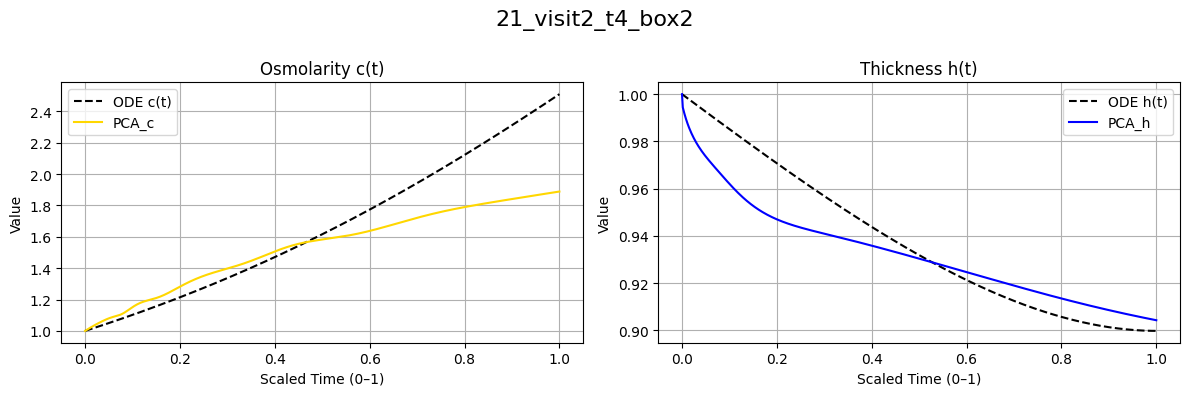

In [234]:
import random

block = random.choice(list(data_blocks.keys()))
block_data = data_blocks[block]

print(f"Processing {block}...")

try:
    params = block_data["params"]
    times, values = zip(*block_data["data"])
    times = np.array(times)
    values = np.array(values)

    if len(times) < 2 or values[0] == 0:
        print(f"Skipping {block} due to insufficient data or division by zero.")
    else:
        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)
        I_input = I_interp.reshape(1, -1)       # Shape: (1, 601)
        I_pca = pca_i.transform(I_input) 

        # Predict with models
        predictions_c = pca_c.inverse_transform(model_c_pca.predict(I_pca)).flatten() 
        predictions_h = pca_h.inverse_transform(model_h_pca.predict(I_pca)).flatten() 

        # Solve ODE
        t, h_ode, c_ode = solve_TF_model_from_block(params)

        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        axs[0].plot(t, c_ode, label="ODE c(t)", color="black", linestyle="--")
        axs[0].plot(t_interp, predictions_c, label="PCA_c", color="gold")
        axs[0].set_title("Osmolarity c(t)")
        axs[0].set_xlabel("Scaled Time (0–1)")
        axs[0].set_ylabel("Value")
        axs[0].grid(True)
        axs[0].legend()

        axs[1].plot(t, h_ode, label="ODE h(t)", color="black", linestyle="--")
        axs[1].plot(t_interp, predictions_h, label="PCA_h", color="blue")
        axs[1].set_title("Thickness h(t)")
        axs[1].set_xlabel("Scaled Time (0–1)")
        axs[1].set_ylabel("Value")
        axs[1].grid(True)
        axs[1].legend()

        fig.suptitle(f"{block}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

except Exception as e:
    print(f"Error processing {block}: {e}")
    


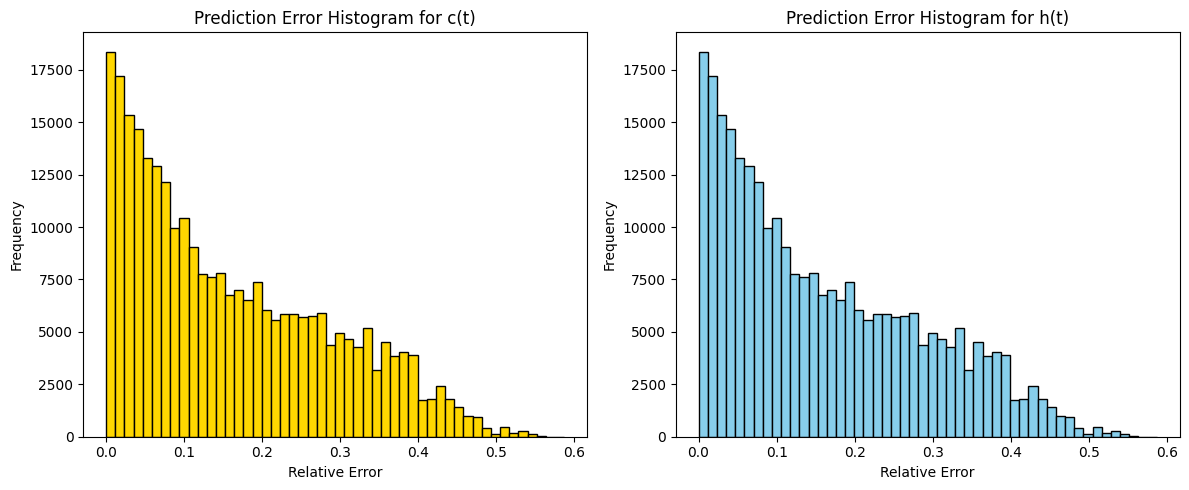

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

errors_c = []
errors_h = []

for block, block_data in data_blocks.items():
    try:
        params = block_data["params"]
        times, values = zip(*block_data["data"])
        times = np.array(times)
        values = np.array(values)

        if len(times) < 2 or values[0] == 0:
            continue

        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        I_input = I_interp.reshape(1, -1)       # Shape: (1, 601)
        I_pca = pca_i.transform(I_input) 

        # Predict with models
        predictions_c = pca_c.inverse_transform(model_c_pca.predict(I_pca)).flatten() 
        predictions_h = pca_h.inverse_transform(model_h_pca.predict(I_pca)).flatten() 

        # Ground truth
        t, h_ode, c_ode = solve_TF_model_from_block(params)

        # Interpolate ODE to match prediction time grid
        c_true = np.interp(t_interp, t, c_ode)
        h_true = np.interp(t_interp, t, h_ode)

        # Error: per-point absolute error
        errors_c.extend(np.abs((pred_c - c_true) / c_true))
        errors_h.extend(np.abs((pred_c - c_true) / c_true))

    except Exception as e:
        print(f"Skipping {block} due to error: {e}")
        continue

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors_c, bins=50, color="gold", edgecolor="black")
plt.title("Prediction Error Histogram for c(t)")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(errors_h, bins=50, color="skyblue", edgecolor="black")
plt.title("Prediction Error Histogram for h(t)")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



In [254]:
save_dir = r"C:/Users/cqyzxy/Desktop/Math/research/Julia/TF2D/sciml/FFN_PCA_ODE"
os.makedirs(save_dir, exist_ok=True)
for block, block_data in data_blocks.items():
    print(f"Processing {block}...")
    try:
        params = block_data["params"]
        times, values = zip(*block_data["data"])
        times = np.array(times)
        values = np.array(values)

        if len(times) < 2 or values[0] == 0:
            print(f"Skipping {block} due to insufficient data or division by zero.")
            continue

        # Normalize and interpolate input
        t_min = times[0]
        t_max = times[-1]
        scaled_times = (times - t_min) / (t_max - t_min)
        normalized_I = values / values[0]

        interp = PchipInterpolator(scaled_times, normalized_I)
        t_interp = np.linspace(0, 1, 601)
        I_interp = interp(t_interp)

        I_input = I_interp.reshape(1, -1)       # Shape: (1, 601)
        I_pca = pca_i.transform(I_input) 

        # Predict with models
        predictions_c_pca = pca_c.inverse_transform(model_c_pca.predict(I_pca)).flatten() 
        predictions_h_pca = pca_h.inverse_transform(model_h_pca.predict(I_pca)).flatten() 

        predictions_c_ffn = model_c.predict(I_interp.reshape(1, -1)).flatten()
        predictions_h_ffn = model_h.predict(I_interp.reshape(1, -1)).flatten()
        t, h_ode, c_ode = solve_TF_model_from_block(params)
        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
        axs[0].plot(t_interp, c_ode, label="ODE c(t)", color="red")
        axs[0].plot(t_interp, predictions_c_ffn, label="FFN_c", color="gold", linestyle="--")
        axs[0].plot(t_interp, predictions_c_pca, label="PCA_c", color="black")
        axs[0].set_title("Osmolarity c(t)")
        axs[0].set_xlabel("Scaled Time (0–1)")
        axs[0].set_ylabel("Value")
        axs[0].grid(True)
        axs[0].legend()
        
        axs[1].plot(t_interp, h_ode, label="ODE h(t)", color="red")
        axs[1].plot(t_interp, predictions_h_ffn, label="FFN_h", color="blue", linestyle="--")
        axs[1].plot(t_interp, predictions_h_pca, label="PCA_h", color="black")
        axs[1].set_title("Thickness h(t)")
        axs[1].set_xlabel("Scaled Time (0–1)")
        axs[1].set_ylabel("Value")
        axs[1].grid(True)
        axs[1].legend()

        fig.suptitle(f"{block}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.98])

        # Save figure
        save_path = os.path.join(save_dir, f"{block}_plot.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

    except Exception as e:
        print(f"Error processing {block}: {e}")

Processing 01_visit1_t10_box1...
Processing 01_visit1_t10_box2...
Processing 01_visit1_t1_box0...
Processing 01_visit1_t1_box1...
Processing 01_visit1_t1_box2...
Processing 01_visit1_t2_box0...
Processing 01_visit1_t2_box2...
Processing 01_visit1_t3_box1...
Processing 01_visit1_t3_box2...
Processing 01_visit1_t3_box3...
Processing 01_visit1_t4_box0...
Processing 01_visit1_t5_box1...
Processing 01_visit1_t5_box2...
Processing 01_visit1_t5_box3...
Processing 01_visit1_t5_box4...
Processing 01_visit1_t6_box0...
Processing 01_visit1_t6_box1...
Processing 01_visit1_t6_box2...
Processing 01_visit1_t8_box0...
Processing 01_visit1_t8_box2...
Processing 01_visit1_t9_box0...
Processing 01_visit1_t9_box1...
Processing 01_visit1_t9_box2...
Processing 01_visit2_t10_box1...
Processing 01_visit2_t10_box2...
Processing 01_visit2_t1_box1...
Processing 01_visit2_t2_box0...
Processing 01_visit2_t2_box1...
Processing 01_visit2_t2_box2...
Processing 01_visit2_t3_box1...
Processing 01_visit2_t3_box2...
Proc

# Dump data plots

In [142]:
def calculate_I(h, f, phi):
    I_raw = (1 - np.exp(-phi * h * f)) / (1 + f ** 2) 
    I_0 = 1 / I_raw[0]
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


Processing 22_visit1_t7_box0...


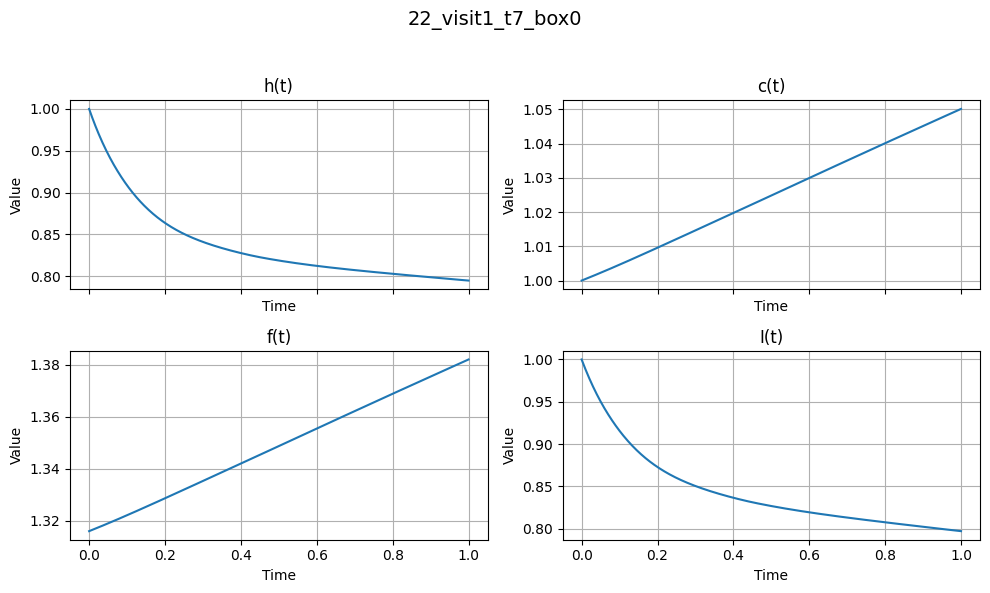

In [219]:
import random

# Pick 1 random block
block = random.choice(list(data_blocks.keys()))
block_data = data_blocks[block]
print(f"Processing {block}...")

try:
    params = block_data["params"]
    times, values = zip(*block_data["data"])
    times = np.array(times)
    values = np.array(values)

    if len(times) < 2 or values[0] == 0:
        print(f"Skipping {block} due to insufficient data or division by zero.")
    else:
        # Solve ODE
        t, h_ode, c_ode = solve_TF_model_from_block(params)
        f_cr = 5.3e-3  # molar
        eps_f = 1.75e7 # m^-1 M^-1
        phi = eps_f * f_cr * params['h0'] * 1e-6
        f_0 = params['f0'] / 0.002  
        f = f_0 * c_ode
        I = calculate_I(h_ode, f, phi)

        # Plot
        fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
        axs[0, 0].plot(t, h_ode)
        axs[0, 0].set_title("h(t)")

        axs[0, 1].plot(t, c_ode)
        axs[0, 1].set_title("c(t)")

        axs[1, 0].plot(t, f)
        axs[1, 0].set_title("f(t)")

        axs[1, 1].plot(t, I)
        axs[1, 1].set_title("I(t)")

        for ax in axs.flat:
            ax.grid(True)
            ax.set_xlabel("Time")
            ax.set_ylabel("Value")

        fig.suptitle(f"{block}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

except Exception as e:
    print(f"Error processing {block}: {e}")

    

# Check if there's increasing I

In [ ]:
I_values_dict = {}  # Dictionary to store I for each block

for block, block_data in data_blocks.items():
    print(f"Processing {block}...")
    try:
        params = block_data["params"]
        times, values = zip(*block_data["data"])
        times = np.array(times)
        values = np.array(values)

        if len(times) < 2 or values[0] == 0:
            print(f"Skipping {block} due to insufficient data or division by zero.")
            continue

        # Solve ODE
        t, h_ode, c_ode = solve_TF_model_from_block(params)
        f_cr = 5.3e-3  # in molar
        eps_f = 1.75e7  # m^-1 M^-1
        phi = eps_f * f_cr * params['h0'] * 1e-6
        f_0 = params['f0'] / 0.002
        f = f_0 * c_ode
        I = calculate_I(h_ode, f, phi)

        # Save to dictionary
        I_values_dict[block] = I

    except Exception as e:
        print(f"Error processing {block}: {e}")
        

In [138]:
I_values_filtered = {
    block: I for block, I in I_values_dict.items() if I[-1] >= I[0]
}


In [151]:
I_values_filtered

{}